# 02 - RUL target construction and leakage-safe validation design

**Goal:** fix the target definition and the validation protocol *before* any model development, and verify both on the real data.

Code under test (all reusable):
- `src/utils.py`: `add_train_rul`, `add_test_rul`, `cap_rul`, `rul_metrics`, `phm08_score`
- `src/components/validation.py`: engine-level folds, test-like truncation, `cross_validate`
- `src/components/data_transformation.py`: `ConditionNormalizer`, `add_causal_features`, `FoldPreprocessor` (fit on training engines only)
- `tests/`: automated target, fold and leakage tests (run in Section 6)

**No final model is trained here.** Section 7 uses a ridge regression *only as a diagnostic probe* to study how the RUL cap behaves inside the validation protocol.

**Test-set hygiene:** the official test files are used in two label-free ways: their *observed lengths* (model inputs, available at prediction time) shape the validation truncation, and the trajectories exist for the final evaluation. The test **labels** (`RUL_FD00x.txt`) are read here only to (a) verify the target construction and (b) run one clearly marked sanity check of the protocol design. They are not used for any modelling or hyper-parameter decision.

In [1]:
import os
import subprocess
import sys
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from scipy import stats
from sklearn.linear_model import Ridge

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.components.data_transformation import FoldPreprocessor
from src.components.validation import (
    DEFAULT_MAX_RUL, DEFAULT_MIN_RUL, DEFAULT_N_CUTS, DEFAULT_N_SPLITS, DEFAULT_SEED, DEFAULT_STRATEGY, WIDE_MAX_RUL,
    cross_validate, iter_folds, last_observed_rows, make_cv_plan, make_truncated_samples, summarise_cv,
)
from src.data_schema import SUBSETS
from src.utils import add_test_rul, add_train_rul, cap_rul, read_cmapss_file, read_rul_file, rul_metrics

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PLAN_DIR = PROJECT_ROOT / "data" / "processed" / "cv_plan"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "validation"
TAB_DIR = PROJECT_ROOT / "reports" / "tables" / "validation"
for d in (PLAN_DIR, FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__} | sklearn {sklearn.__version__}")

python 3.13.7 | pandas 3.0.6 | numpy 2.5.3 | sklearn 1.9.1


In [2]:
# Same palette/style as 01_eda (FD001-FD004 slots validated colour-blind-safe, all pairs).
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
FD_COLORS = dict(zip(SUBSETS, ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]))
PAIR = ["#2a78d6", "#eb6834"]  # two-series comparisons
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8, "legend.frameon": False,
    "lines.linewidth": 1.5, "figure.dpi": 90,
})


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    print("saved", (FIG_DIR / f"{name}.png").relative_to(PROJECT_ROOT))


def savetab(df, name, index=True):
    df.to_csv(TAB_DIR / f"{name}.csv", index=index)
    print("saved", (TAB_DIR / f"{name}.csv").relative_to(PROJECT_ROOT))

In [3]:
data = {}
for s in SUBSETS:
    rul = read_rul_file(s, RAW_DIR)
    data[s] = {
        "train": add_train_rul(read_cmapss_file(s, "train", RAW_DIR)),
        "test": add_test_rul(read_cmapss_file(s, "test", RAW_DIR), rul),
        "rul": rul,
    }
    data[s]["test_lengths"] = data[s]["test"].groupby("unit_id")["cycle"].max().to_numpy()

## 1. RUL target construction

**Training (run-to-failure):** `RUL(unit, t) = T_unit − t`, where `T_unit` is the unit's last cycle (failure). The failure row has RUL 0, and the first row has `T − 1`.

**Test (truncated):** the RUL file gives the remaining cycles *after* the last observed cycle `L`, so `RUL(unit, t) = RUL_file(unit) + (L − t)`. This is the same convention as training: in both cases RUL counts the cycles that remain after the current one.

**Validation sample cut at cycle c:** `target = T − c`, identical to the training RUL at row `c` (tested).

**Capped (piecewise-linear) target:** `min(RUL, cap)`. This is used **only as the training target**. Evaluation is against the uncapped truth (Section 7).

In [4]:
checks = []
for s in SUBSETS:
    tr, te, rul = data[s]["train"], data[s]["test"], data[s]["rul"]
    life = tr.groupby("unit_id")["cycle"].transform("max")
    last_tr = tr.loc[tr.groupby("unit_id")["cycle"].idxmax()]
    last_te = te.loc[te.groupby("unit_id")["cycle"].idxmax()].set_index("unit_id")["RUL"].sort_index()
    checks.append({
        "subset": s,
        "train: RUL == T - t (all rows)": bool((tr.RUL == life - tr.cycle).all()),
        "train: RUL == 0 at failure row": bool((last_tr.RUL == 0).all()),
        "train: steps of -1": bool((tr.sort_values(["unit_id", "cycle"]).groupby("unit_id").RUL.diff().dropna() == -1).all()),
        "test: last-row RUL == RUL file": bool((last_te.to_numpy() == rul.set_index("unit_id").RUL.sort_index().to_numpy()).all()),
        "test: steps of -1": bool((te.sort_values(["unit_id", "cycle"]).groupby("unit_id").RUL.diff().dropna() == -1).all()),
        "train RUL range": f"{tr.RUL.min()}-{tr.RUL.max()}",
        "test RUL range (all rows)": f"{te.RUL.min()}-{te.RUL.max()}",
    })
target_checks = pd.DataFrame(checks).set_index("subset")
savetab(target_checks, "target_checks")
target_checks

saved reports\tables\validation\target_checks.csv


,train: RUL == T - t (all rows),train: RUL == 0 at failure row,train: steps of -1,test: last-row RUL == RUL file,test: steps of -1,train RUL range,test RUL range (all rows)
subset,,,,,,,
FD001,True,True,True,True,True,0-361,7-340
FD002,True,True,True,True,True,0-377,6-377
FD003,True,True,True,True,True,0-524,6-483
FD004,True,True,True,True,True,0-542,6-553


### 1.1 Manual inspection of sample engines

In [5]:
tr = data["FD001"]["train"]
u = 1
eng = tr.loc[tr.unit_id == u, ["unit_id", "cycle", "RUL"]].assign(**{"RUL cap 125": lambda d: cap_rul(d.RUL, 125)})
print(f"FD001 train unit {u}: lifespan {eng.cycle.max()} cycles")
pd.concat([eng.head(3), eng.iloc[[eng.cycle.max() - 126 - 1, eng.cycle.max() - 125 - 1, eng.cycle.max() - 124 - 1]], eng.tail(3)])

FD001 train unit 1: lifespan 192 cycles


,unit_id,cycle,RUL,RUL cap 125
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
65,1,66,126,125
66,1,67,125,125
67,1,68,124,124
189,1,190,2,2
190,1,191,1,1
191,1,192,0,0


In [6]:
te, rul = data["FD004"]["test"], data["FD004"]["rul"]
u = int(rul.RUL.idxmax()) + 1  # the test engine with the largest true RUL
eng = te.loc[te.unit_id == u, ["unit_id", "cycle", "RUL"]]
print(f"FD004 test unit {u}: observed {eng.cycle.max()} cycles, RUL file says {rul.loc[rul.unit_id == u, 'RUL'].item()}")
pd.concat([eng.head(2), eng.tail(3)])

FD004 test unit 127: observed 98 cycles, RUL file says 195


,unit_id,cycle,RUL
22149,127,1,292
22150,127,2,291
22244,127,96,197
22245,127,97,196
22246,127,98,195


saved reports\figures\validation\01_target_examples.png


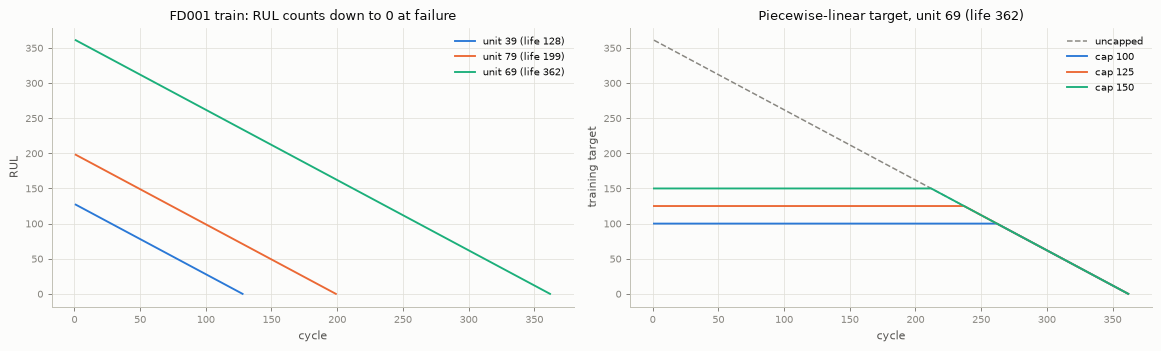

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tr = data["FD001"]["train"]
lives = tr.groupby("unit_id").cycle.max().sort_values()
example_units = [lives.index[0], lives.index[len(lives) // 2], lives.index[-1]]  # shortest, median, longest life
for i, u in enumerate(example_units):
    e = tr[tr.unit_id == u]
    axes[0].plot(e.cycle, e.RUL, color=[PAIR[0], PAIR[1], "#1baf7a"][i], label=f"unit {u} (life {e.cycle.max()})")
axes[0].set(title="FD001 train: RUL counts down to 0 at failure", xlabel="cycle", ylabel="RUL")
axes[0].legend()
e = tr[tr.unit_id == example_units[-1]]
axes[1].plot(e.cycle, e.RUL, color=MUTED, lw=1.2, ls="--", label="uncapped")
for cap, col in [(100, PAIR[0]), (125, PAIR[1]), (150, "#1baf7a")]:
    axes[1].plot(e.cycle, cap_rul(e.RUL, cap), color=col, label=f"cap {cap}")
axes[1].set(title=f"Piecewise-linear target, unit {example_units[-1]} (life {e.cycle.max()})", xlabel="cycle", ylabel="training target")
axes[1].legend()
fig.tight_layout()
savefig(fig, "01_target_examples")
plt.show()

### 1.2 Target distributions and how much a cap clips

In [8]:
CAPS = [90, 100, 110, 120, 125, 130, 140, 150, 175, 200]
clip = pd.DataFrame({s: {cap: (data[s]["train"].RUL > cap).mean() for cap in CAPS} for s in SUBSETS}).round(3)
clip.index.name = "cap"
print("Fraction of TRAINING rows whose target is clipped by the cap:")
savetab(clip, "fraction_rows_clipped")
clip

Fraction of TRAINING rows whose target is clipped by the cap:
saved reports\tables\validation\fraction_rows_clipped.csv


,FD001,FD002,FD003,FD004
cap,,,,
90,0.559,0.560,0.632,0.630
100,0.510,0.512,0.591,0.589
110,0.462,0.463,0.551,0.549
120,0.414,0.415,0.511,0.508
125,0.389,0.391,0.490,0.488
130,0.365,0.367,0.470,0.467
140,0.318,0.319,0.430,0.427
150,0.272,0.273,0.390,0.388
175,0.171,0.173,0.297,0.296


saved reports\figures\validation\02_target_distributions.png


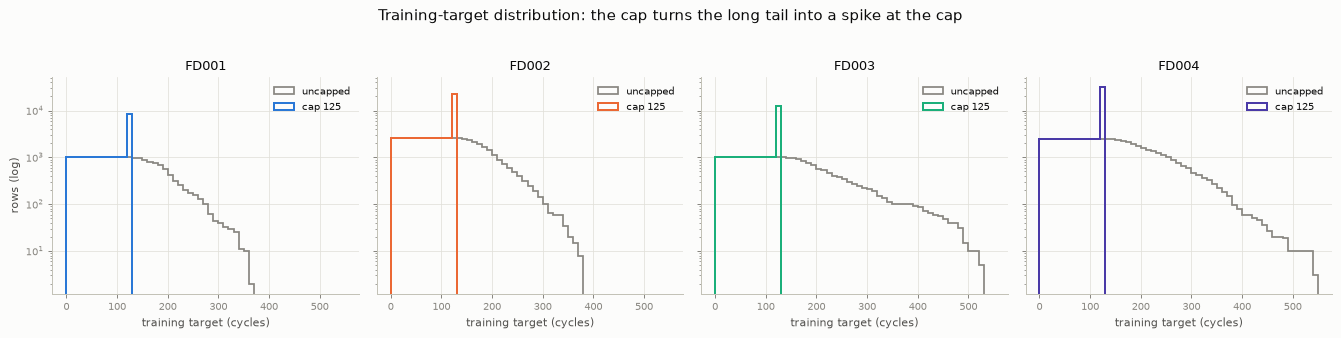

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, s in zip(axes, SUBSETS):
    r = data[s]["train"].RUL
    ax.hist(r, bins=np.arange(0, 560, 10), histtype="step", lw=1.4, color=MUTED, label="uncapped")
    ax.hist(cap_rul(r, 125), bins=np.arange(0, 560, 10), histtype="step", lw=1.6, color=FD_COLORS[s], label="cap 125")
    ax.set(title=s, xlabel="training target (cycles)", yscale="log")
    ax.legend()
axes[0].set_ylabel("rows (log)")
fig.suptitle("Training-target distribution: the cap turns the long tail into a spike at the cap", y=1.03)
fig.tight_layout()
savefig(fig, "02_target_distributions")
plt.show()

## 2. Engine-level folds

- 5 folds per subset, built from **whole engines**, never rows.
- Engines are sorted by lifespan and fold labels are permuted within consecutive blocks of 5 (seed 42), so every fold gets a similar lifespan distribution.
- Folds are built **per subset**. Unit ids restart at 1 in every file, so an id only identifies an engine within one subset and split.

In [10]:
plans, wide_plans = {}, {}
for s in SUBSETS:
    # Primary plan: defaults = 5 engine folds, 10 cuts per validation engine, true RUL at cut uniform in [6, 150].
    folds, cuts = make_cv_plan(data[s]["train"], n_splits=DEFAULT_N_SPLITS, n_cuts=DEFAULT_N_CUTS,
                               strategy=DEFAULT_STRATEGY, min_rul=DEFAULT_MIN_RUL, max_rul=DEFAULT_MAX_RUL, seed=DEFAULT_SEED)
    plans[s] = (folds, cuts)
    # Secondary robustness plan: same folds, RUL at cut up to 190 (the paper's validation-set range).
    wide_folds, wide_cuts = make_cv_plan(data[s]["train"], max_rul=WIDE_MAX_RUL, seed=DEFAULT_SEED)
    assert wide_folds.equals(folds)
    wide_plans[s] = (folds, wide_cuts)
    folds.to_csv(PLAN_DIR / f"{s}_folds.csv", index=False)
    cuts.to_csv(PLAN_DIR / f"{s}_val_cuts.csv", index=False)
    wide_cuts.to_csv(PLAN_DIR / f"{s}_val_cuts_wide.csv", index=False)
print("CV plans saved to", PLAN_DIR.relative_to(PROJECT_ROOT), "(deterministic: regenerated identically from the seed)")

balance = pd.concat({s: plans[s][0].groupby("fold")["lifespan"].agg(["count", "mean", "median", "min", "max"]).round(1)
                     for s in SUBSETS})
balance.columns = ["engines", "life mean", "life median", "life min", "life max"]
savetab(balance, "fold_balance")
balance

CV plans saved to data\processed\cv_plan (deterministic: regenerated identically from the seed)
saved reports\tables\validation\fold_balance.csv


engines  life mean  life median  life min  life max
      fold                                                     
FD001 0          20      203.6        199.0       147       293
      1          20      206.9        198.5       137       336
      2          20      205.4        197.0       135       313
      3          20      207.0        197.0       137       341
      4          20      208.6        199.5       128       362
FD002 0          52      206.3        198.0       136       343
      1          52      206.9        199.0       135       365
      2          52      207.3        199.0       129       347
      3          52      207.2        199.5       133       378
      4          52      206.2        199.5       128       344
FD003 0          20      243.0        220.0       156       459
      1          20      249.6        220.5       153       491
      2          20      247.3        218.0       147       481
      3          20      247.0        217.5       152       494
      4          20      249.2        221.5       145       525
FD004 0          50      247.0        233.5       143       489
      1          49      241.8        234.0       139       399
      2          50      248.5        234.5       131       543
      3          50      246.9        234.5       134       446
      4          50      245.6        234.0       128       457

In [11]:
# Explicit disjointness check on the saved plans.
for s in SUBSETS:
    for k, tr_, va_ in iter_folds(data[s]["train"], plans[s][0]):
        assert set(tr_.unit_id).isdisjoint(va_.unit_id)
print("every fold: training and validation engines are disjoint")

every fold: training and validation engines are disjoint


## 3. Test-like validation samples

A test engine is observed up to some cycle `L`, and **one** RUL is predicted at `L`. Each validation engine is therefore turned into up to 10 truncated samples:
- **Cut point:** the true RUL at the cut, `T − L`, is drawn uniformly (distinct values) from **[6, 150]**.
- **Materialisation:** each sample contains only cycles `1..L`. Later rows are deleted, not masked.
- **Prediction:** one prediction per sample, at its last observed row.

**Choosing the cut distribution without the test labels.** The paper (Sec. VI) documents how its held-out sets were truncated: test RULs ranged 10-150, validation RULs 6-190. Six candidate designs are compared below on a **label-free** criterion: how well the validation *observed lengths* match the official test *observed lengths* (lengths are model inputs, available at prediction time). The designs combine:
- cut strategy: uniform, or drawn from the test lengths;
- RUL bound: none, 150 or 190.

In [12]:
CONFIGS = [("uniform", 150), ("uniform", 190), ("uniform", None),
           ("test_lengths", 150), ("test_lengths", 190), ("test_lengths", None)]
candidate_cuts = {(s, st, mx): make_cv_plan(data[s]["train"], data[s]["test_lengths"], strategy=st, max_rul=mx)[1]
                  for s in SUBSETS for st, mx in CONFIGS}

realism = []
for (s, st, mx), c in candidate_cuts.items():
    realism.append({
        "subset": s, "design": f"{st}, max RUL {mx if mx else 'none'}", "samples": len(c), "engines": c.unit_id.nunique(),
        "KS length vs test (label-free)": stats.ks_2samp(c.cut_cycle, data[s]["test_lengths"]).statistic,
        "RUL at cut median": c.rul_at_cut.median(), "RUL at cut max": c.rul_at_cut.max(),
    })
realism = pd.DataFrame(realism).round(3)
savetab(realism, "truncation_design_comparison", index=False)
realism.pivot(index="design", columns="subset", values="KS length vs test (label-free)")

saved reports\tables\validation\truncation_design_comparison.csv


subset,FD001,FD002,FD003,FD004
design,,,,
"test_lengths, max RUL 150",0.064,0.072,0.048,0.081
"test_lengths, max RUL 190",0.093,0.115,0.095,0.104
"test_lengths, max RUL none",0.127,0.156,0.204,0.197
"uniform, max RUL 150",0.088,0.063,0.051,0.055
"uniform, max RUL 190",0.186,0.144,0.108,0.072
"uniform, max RUL none",0.246,0.202,0.219,0.220


In [13]:
# The chosen design is what make_cv_plan produces by default.
for s in SUBSETS:
    pd.testing.assert_frame_equal(plans[s][1], candidate_cuts[(s, "uniform", 150)])
plans_summary = pd.DataFrame({s: {"validation samples": len(plans[s][1]), "engines validated": plans[s][1].unit_id.nunique(),
                                  "engines": data[s]["train"].unit_id.nunique(),
                                  "RUL at cut min/median/max": f"{plans[s][1].rul_at_cut.min()}/{plans[s][1].rul_at_cut.median():.0f}/{plans[s][1].rul_at_cut.max()}",
                                  "observed length min/median/max": f"{plans[s][1].cut_cycle.min()}/{plans[s][1].cut_cycle.median():.0f}/{plans[s][1].cut_cycle.max()}"}
                              for s in SUBSETS}).T
plans_summary

,validation samples,engines validated,engines,RUL at cut min/median/max,observed length min/median/max
FD001,1000,100,100,6/76/150,3/127/330
FD002,2600,260,260,6/77/150,1/126/352
FD003,1000,100,100,6/76/150,6/152/511
FD004,2490,249,249,6/78/150,1/158/535


**Result (label-free).**
- Bounding the RUL at **150** (the paper's test range) gives the closest length match in every subset, for both strategies (KS ≈ 0.05-0.09).
- Without a bound, KS is 0.13-0.25. Long-lived training engines then produce samples with RULs up to ~490, which never occur in the test scenario.
- The uniform strategy matches about as well as sampling the test lengths, and it does not depend on the test files at all.

**Chosen:** uniform RUL in [6, 150]. **Secondary robustness plan:** uniform RUL in [6, 190].

### 3.1 One-time protocol sanity check against the test labels

*Run once, after the design was fixed by the label-free criterion above, to confirm it. Not used for any modelling decision.*

saved reports\figures\validation\03_validation_vs_test_distributions.png


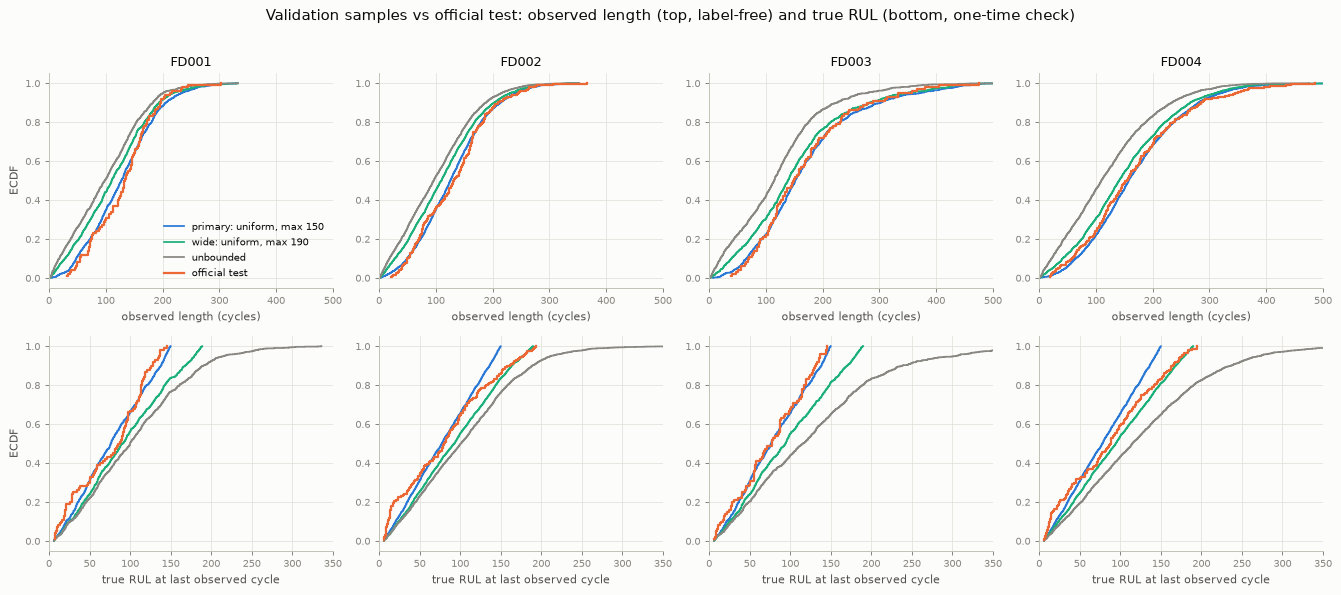

saved reports\tables\validation\truncation_sanity_check_vs_test_rul.csv


KS RUL at cut vs test RUL                      share of test RULs above design max                    
subset                                        FD001  FD002  FD003  FD004                               FD001  FD002 FD003  FD004
design                                                                                                                          
primary: uniform, max 150                     0.106  0.139  0.066  0.169                                 0.0  0.139   0.0  0.169
unbounded                                     0.285  0.170  0.370  0.205                                 0.0  0.000   0.0  0.000
wide: uniform, max 190                        0.221  0.137  0.225  0.097                                 0.0  0.015   0.0  0.016

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
sanity = []
designs = [("primary: uniform, max 150", "uniform", 150, PAIR[0]), ("wide: uniform, max 190", "uniform", 190, "#1baf7a"),
           ("unbounded", "uniform", None, MUTED)]
for j, s in enumerate(SUBSETS):
    test_len, test_rul = data[s]["test_lengths"], data[s]["rul"].RUL.to_numpy()
    for name, st, mx, col in designs:
        c = candidate_cuts[(s, st, mx)]
        for i, v in enumerate([c.cut_cycle, c.rul_at_cut]):
            x = np.sort(v)
            axes[i, j].step(x, np.arange(1, len(x) + 1) / len(x), where="post", color=col, lw=1.4, label=name)
        sanity.append({"subset": s, "design": name, "KS RUL at cut vs test RUL": stats.ks_2samp(c.rul_at_cut, test_rul).statistic,
                       "share of test RULs above design max": float(np.mean(test_rul > (mx or np.inf)))})
    for i, ref in enumerate([test_len, test_rul]):
        x = np.sort(ref)
        axes[i, j].step(x, np.arange(1, len(x) + 1) / len(x), where="post", color=PAIR[1], lw=1.8, label="official test")
    axes[0, j].set(title=s, xlabel="observed length (cycles)", xlim=(0, 500))
    axes[1, j].set(xlabel="true RUL at last observed cycle", xlim=(0, 350))
axes[0, 0].set_ylabel("ECDF")
axes[1, 0].set_ylabel("ECDF")
axes[0, 0].legend(loc="lower right")
fig.suptitle("Validation samples vs official test: observed length (top, label-free) and true RUL (bottom, one-time check)", y=1.01)
fig.tight_layout()
savefig(fig, "03_validation_vs_test_distributions")
plt.show()
sanity = pd.DataFrame(sanity).round(3)
savetab(sanity, "truncation_sanity_check_vs_test_rul", index=False)
sanity.pivot(index="design", columns="subset", values=["KS RUL at cut vs test RUL", "share of test RULs above design max"])

**Result.**
- **FD001/FD003:** the primary design reproduces the test RUL distribution well (KS 0.11 / 0.07), and no test engine lies outside [6, 150].
- **FD002/FD004:** 14% / 17% of the official test engines have a true RUL > 150 (max 194 / 195), which the primary plan cannot represent. The wide plan covers them (KS 0.14 / 0.10).
- **Decision:** the primary design stays as chosen above. Changing it now would be tuning the protocol to the test labels. Instead:
  - the wide plan is reported alongside the primary plan for every model;
  - the cap-selection rule leans towards larger caps (Section 7).
- **Short histories:** 0.6-2.3% of validation samples have fewer than 19 observed cycles, the shortest test trajectory. This makes validation marginally harder than the test, not easier.

### 3.2 Manual inspection: one validation engine and its truncated samples

In [15]:
s = "FD001"
folds, cuts = plans[s]
u = int(cuts.unit_id.iloc[0])
eng_cuts = cuts[cuts.unit_id == u]
display(eng_cuts)

samples = make_truncated_samples(data[s]["train"], eng_cuts)
summary = samples.groupby("sample_id").agg(rows=("cycle", "size"), first_cycle=("cycle", "min"), last_cycle=("cycle", "max"))
summary = summary.join(eng_cuts.set_index("sample_id")[["cut_cycle", "rul_at_cut"]])
summary["rows == cut and last == cut"] = (summary.rows == summary.cut_cycle) & (summary.last_cycle == summary.cut_cycle)
summary

,sample_id,unit_id,lifespan,cut_cycle,rul_at_cut,fold
0,0,3,179,29,150,0
1,1,3,179,47,132,0
2,2,3,179,55,124,0
3,3,3,179,77,102,0
4,4,3,179,80,99,0
5,5,3,179,95,84,0
6,6,3,179,102,77,0
7,7,3,179,110,69,0
8,8,3,179,131,48,0
9,9,3,179,135,44,0


,rows,first_cycle,last_cycle,cut_cycle,rul_at_cut,rows == cut and last == cut
sample_id,,,,,,
0,29,1,29,29,150,True
1,47,1,47,47,132,True
2,55,1,55,55,124,True
3,77,1,77,77,102,True
4,80,1,80,80,99,True
5,95,1,95,95,84,True
6,102,1,102,102,77,True
7,110,1,110,110,69,True
8,131,1,131,131,48,True


saved reports\figures\validation\04_sample_engine_cuts.png


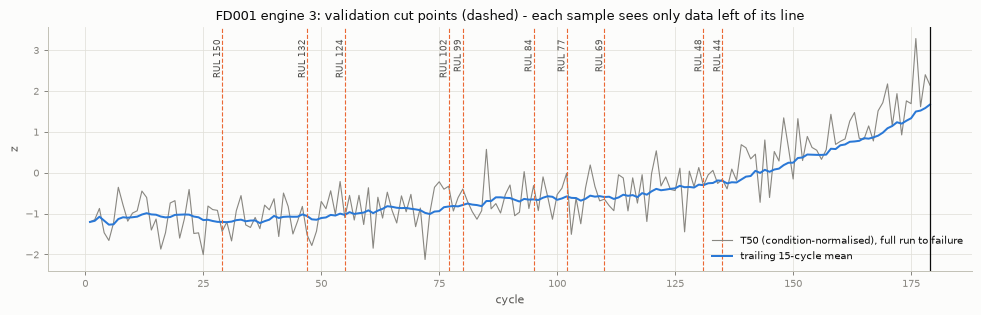

In [16]:
pre = FoldPreprocessor().fit(data[s]["train"][data[s]["train"].unit_id != u])
full = pre.normalizer_.transform(data[s]["train"][data[s]["train"].unit_id == u])
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(full.cycle, full.T50, color=MUTED, lw=0.9, label="T50 (condition-normalised), full run to failure")
ax.plot(full.cycle, full.T50.rolling(15, min_periods=1).mean(), color=PAIR[0], lw=1.6, label="trailing 15-cycle mean")
for _, c in eng_cuts.iterrows():
    ax.axvline(c.cut_cycle, color=PAIR[1], lw=0.9, ls="--")
    ax.text(c.cut_cycle, ax.get_ylim()[1] * 0.92, f"RUL {c.rul_at_cut}", rotation=90, fontsize=7, color=INK2, ha="right", va="top")
ax.axvline(full.cycle.max(), color=INK, lw=1)
ax.set(title=f"{s} engine {u}: validation cut points (dashed) - each sample sees only data left of its line",
       xlabel="cycle", ylabel="z")
ax.legend(loc="lower right")
fig.tight_layout()
savefig(fig, "04_sample_engine_cuts")
plt.show()

In [17]:
# The prediction row of each sample: features from the truncated history equal the features of the
# full trajectory at that cycle (causality), and the row is exactly at the cut.
X_samples = last_observed_rows(pre.transform(samples, group_cols=("sample_id",)))
X_full = pre.transform(data[s]["train"][data[s]["train"].unit_id == u])
X_full = X_full.set_index("cycle").loc[X_samples.cycle, pre.feature_names_]
print("max |feature(truncated) - feature(full trajectory at same cycle)| =",
      float(np.abs(X_samples[pre.feature_names_].to_numpy() - X_full.to_numpy()).max()))
X_samples[["sample_id", "unit_id", "cycle", "T50_mean15", "T50_slope30", "T50_delta_base"]]

max |feature(truncated) - feature(full trajectory at same cycle)| = 0.0


,sample_id,unit_id,cycle,T50_mean15,T50_slope30,T50_delta_base
0,0,3,29,-1.346565,-0.276105,-1.016816
1,1,3,47,-1.170403,-0.176637,-0.960925
2,2,3,55,-1.137417,-0.077771,-0.416613
3,3,3,77,-0.888005,-0.001163,-0.080995
4,4,3,80,-0.842706,-0.094391,-0.174880
5,5,3,95,-0.677599,0.055920,-0.299601
6,6,3,102,-0.588889,-0.135491,-0.170199
7,7,3,110,-0.607224,-0.077862,0.029410
8,8,3,131,-0.254721,0.082873,0.009586
9,9,3,135,-0.126374,0.001189,0.307210


## 4. Feature causality

`add_causal_features` produces, per sensor:
- the current value;
- trailing mean, std and least-squares slope over windows of 5/15/30 cycles, using fewer cycles when fewer are available;
- `delta_base`: the change from the engine's own early-life baseline, the mean of its first ≤ 10 cycles.

Every one of these uses only cycles ≤ t of the same trajectory. Section 3.2 already showed that features from a truncated sample equal features from the full trajectory at the same cycle. Section 6 tests the same property on many engines and cuts, together with:
- perturbation of future rows;
- cross-engine independence;
- row-order independence.

## 5. Fit-on-training-only preprocessing

`FoldPreprocessor.fit(train_fold)` learns:
- per-condition sensor statistics;
- feature means and stds.

`transform` only applies them. In `cross_validate`, the preprocessor is fitted on the training-fold engines and asserts that none of the validation engines was seen. Validation samples are transformed from their truncated histories. For the final model the same object is fitted on all training engines of a subset and applied to the official test trajectories.

In [18]:
s = "FD004"
_, tr_, va_ = next(iter_folds(data[s]["train"], plans[s][0]))
pre = FoldPreprocessor().fit(tr_)
print("engines used to fit:", len(pre.fit_units_), "| validation engines:", va_.unit_id.nunique(),
      "| overlap:", len(pre.fit_units_ & set(va_.unit_id)))
print("normaliser fitted on", pre.normalizer_.n_fit_rows_, "rows (training fold) of", len(data[s]["train"]), "total")
print("features:", len(pre.feature_names_))

engines used to fit: 199 | validation engines: 50 | overlap: 0
normaliser fitted on 48897 rows (training fold) of 61249 total
features: 187


## 6. Automated tests (targets, folds, leakage)

In [19]:
t0 = time.time()
res = subprocess.run([sys.executable, "-m", "pytest", "tests", "-q", "-p", "no:cacheprovider"],
                     cwd=PROJECT_ROOT, capture_output=True, text=True)
print(res.stdout[-1500:])
print(f"exit code {res.returncode} ({time.time() - t0:.0f}s)")
assert res.returncode == 0, "tests failed"

......................................................                   [100%]
54 passed in 21.26s

exit code 0 (22s)


Before this notebook was written, the leakage tests were themselves checked by injecting two deliberate bugs:
- **A centred (look-ahead) rolling window** made the 3 causality tests fail.
- **Fitting the preprocessor on all engines inside `cross_validate`** made the CV spy test fail.

In both cases the original code was restored afterwards.

## 7. RUL cap as a hyper-parameter

The cap trades two errors against each other:
- **Too low:** samples whose true RUL exceeds the cap can never be predicted correctly.
- **Too high:** the model must predict large RULs in early life, where the sensors are still near-healthy (EDA Section 10.6) and the RUL is barely identifiable.

### 7.1 Error floor of a perfect capped predictor
If a model predicted the capped target perfectly, `ŷ = min(RUL, cap)`, its error against the true RUL on the validation samples would be:

In [20]:
ALL_CAPS = [None] + CAPS
floor = []
for plan_name, plan_set in [("primary", plans), ("wide", wide_plans)]:
    for s in SUBSETS:
        y = plan_set[s][1].rul_at_cut.to_numpy()
        for cap in ALL_CAPS:
            m = rul_metrics(y, cap_rul(y, cap))
            floor.append({"plan": plan_name, "subset": s, "cap": "none" if cap is None else cap, "floor RMSE": m["rmse"],
                          "floor PHM08/sample": m["phm08_score_per_sample"], "share of samples above cap": float(np.mean(y > (cap or np.inf)))})
floor = pd.DataFrame(floor)
savetab(floor, "cap_error_floor", index=False)
floor.pivot(index="cap", columns=["plan", "subset"], values="floor RMSE").round(2)

saved reports\tables\validation\cap_error_floor.csv


plan   primary                        wide                     
subset   FD001  FD002  FD003  FD004  FD001  FD002  FD003  FD004
cap                                                            
90       22.69  22.41  22.85  22.50  38.89  38.43  40.67  40.46
100      17.40  17.08  17.54  17.17  33.06  32.51  34.69  34.42
110      12.60  12.26  12.71  12.33  27.59  26.96  29.05  28.73
120       8.33   8.01   8.41   8.05  22.50  21.82  23.76  23.40
125       6.38   6.12   6.45   6.14  20.10  19.40  21.25  20.88
130       4.60   4.40   4.66   4.42  17.82  17.10  18.85  18.47
140       1.59   1.56   1.62   1.57  13.58  12.87  14.36  13.98
150       0.00   0.00   0.00   0.00   9.76   9.14  10.32   9.94
175       0.00   0.00   0.00   0.00   2.12   2.11   2.33   2.24
200       0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00
none      0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00

On the primary plan (RUL ≤ 150), any cap ≥ 150 has zero floor, and caps below ~120 cost more than 5 RMSE before a model makes any other error.

### 7.2 Diagnostic probe: the cap inside the full protocol

A ridge regression (α = 1) on the causal features is run through the exact protocol: engine folds, training-fold-only preprocessing, one prediction per truncated validation sample, and scoring against the **uncapped** truth. The only thing that changes is the cap.

This is a **diagnostic, not a candidate model**. A linear model cannot represent the flat-then-falling relationship and is therefore unusually sensitive to the cap. Non-linear models will have a different optimum, so the cap must be **re-tuned for each model family**.

In [21]:
t0 = time.time()
cv_preds = {}
for plan_name, plan_set in [("primary", plans), ("wide", wide_plans)]:
    for s in SUBSETS:
        folds, cuts = plan_set[s]
        cv_preds[(plan_name, s)] = cross_validate(data[s]["train"], folds, cuts, make_preprocessor=FoldPreprocessor,
                                                  make_model=lambda: Ridge(alpha=1.0), caps=ALL_CAPS)
        print(f"{plan_name} {s}: {len(cuts)} validation samples x {len(ALL_CAPS)} caps  ({time.time() - t0:.0f}s)")

cap_cv = pd.concat({k: summarise_cv(v) for k, v in cv_preds.items()}, names=["plan", "subset"]).reset_index(level=[0, 1])
cap_cv["cap"] = cap_cv["cap"].map(lambda c: "none" if pd.isna(c) else int(c))
savetab(cap_cv, "cap_sweep_diagnostic_ridge", index=False)
cap_cv.pivot(index="cap", columns=["plan", "subset"], values="rmse").round(2)

primary FD001: 1000 validation samples x 11 caps  (16s)


primary FD002: 2600 validation samples x 11 caps  (54s)


primary FD003: 1000 validation samples x 11 caps  (72s)


primary FD004: 2490 validation samples x 11 caps  (103s)


wide FD001: 1000 validation samples x 11 caps  (115s)


wide FD002: 2600 validation samples x 11 caps  (162s)


wide FD003: 1000 validation samples x 11 caps  (181s)


wide FD004: 2490 validation samples x 11 caps  (224s)


saved reports\tables\validation\cap_sweep_diagnostic_ridge.csv


plan   primary                        wide                     
subset   FD001  FD002  FD003  FD004  FD001  FD002  FD003  FD004
cap                                                            
90       26.33  26.52  27.29  27.85  40.63  40.47  42.54  43.36
100      22.92  23.08  24.08  24.54  36.14  35.94  37.92  38.75
110      20.57  20.76  21.99  22.32  32.47  32.26  34.11  34.89
120      19.35  19.60  21.04  21.25  29.65  29.48  31.16  31.87
125      19.13  19.43  20.96  21.12  28.56  28.42  30.01  30.69
130      19.15  19.48  21.10  21.24  27.69  27.59  29.08  29.73
140      19.69  20.12  21.89  22.07  26.54  26.51  27.81  28.45
150      20.68  21.22  23.12  23.45  26.05  26.09  27.28  27.94
175      23.59  24.41  27.01  27.88  26.49  26.80  28.20  29.10
200      25.90  26.98  30.82  32.18  27.80  28.21  30.67  31.85
none     29.25  30.78  46.71  44.11  30.46  31.13  47.39  42.94

saved reports\figures\validation\05_cap_sweep.png


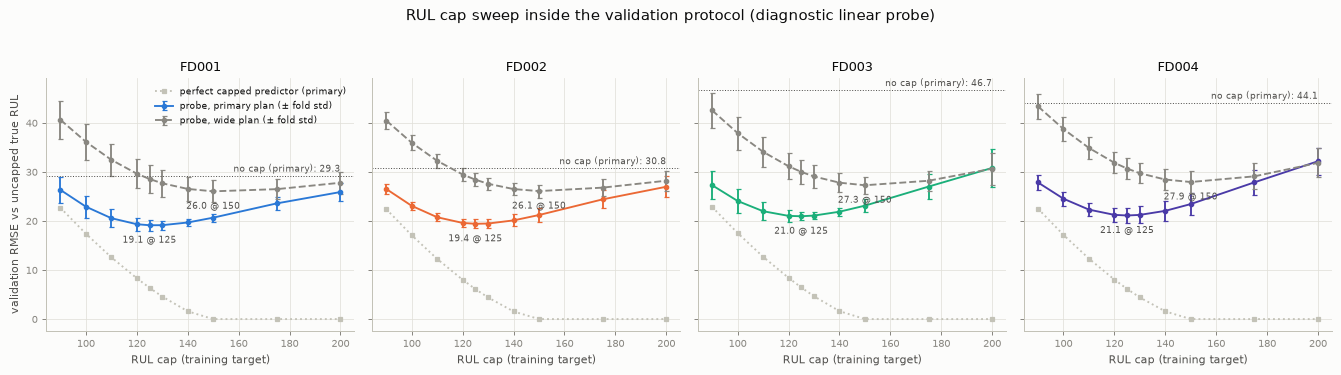

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
for ax, s in zip(axes, SUBSETS):
    for plan_name, ls, col in [("primary", "-", FD_COLORS[s]), ("wide", "--", MUTED)]:
        c = cap_cv[(cap_cv.plan == plan_name) & (cap_cv.subset == s) & (cap_cv.cap != "none")]
        ax.errorbar(c.cap.astype(int), c.rmse, yerr=c.rmse_fold_std, color=col, ls=ls, marker="o", ms=3.5, capsize=2,
                    label=f"probe, {plan_name} plan (± fold std)")
        best = c.loc[c.rmse.idxmin()]
        ax.annotate(f"{best.rmse:.1f} @ {best.cap}", (int(best.cap), best.rmse), xytext=(0, -14), textcoords="offset points",
                    fontsize=7.5, ha="center", color=INK2)
    f = floor[(floor.plan == "primary") & (floor.subset == s) & (floor.cap != "none")]
    ax.plot(f.cap.astype(int), f["floor RMSE"], color=AXIS, ls=":", marker="s", ms=3, label="perfect capped predictor (primary)")
    none = cap_cv[(cap_cv.plan == "primary") & (cap_cv.subset == s) & (cap_cv.cap == "none")].rmse.item()
    ax.axhline(none, color=INK2, lw=0.8, ls=":")
    ax.text(200, none + 0.8, f"no cap (primary): {none:.1f}", fontsize=7.5, color=INK2, ha="right")
    ax.set(title=s, xlabel="RUL cap (training target)")
axes[0].set_ylabel("validation RMSE vs uncapped true RUL")
axes[0].legend(loc="upper right", fontsize=7)
fig.suptitle("RUL cap sweep inside the validation protocol (diagnostic linear probe)", y=1.03)
fig.tight_layout()
savefig(fig, "05_cap_sweep")
plt.show()

In [23]:
# Where the errors come from (primary plan): RMSE by true-RUL band for a few caps.
rows = []
for s in SUBSETS:
    p = cv_preds[("primary", s)].copy()
    p["cap"] = p["cap"].map(lambda c: "none" if pd.isna(c) else int(c))
    p["true RUL band"] = pd.cut(p.y_true, [0, 25, 50, 100, 150], labels=["≤25", "26-50", "51-100", "101-150"])
    t = p[p.cap.isin(["none", 100, 125, 150])].groupby(["cap", "true RUL band"], observed=True).apply(
        lambda g: np.sqrt(np.mean((g.y_pred - g.y_true) ** 2))).unstack()
    rows.append(t.assign(subset=s).set_index("subset", append=True).reorder_levels([1, 0]))
band_rmse = pd.concat(rows).round(1)
savetab(band_rmse, "cap_sweep_rmse_by_rul_band")
band_rmse

saved reports\tables\validation\cap_sweep_rmse_by_rul_band.csv


true RUL band   ≤25  26-50  51-100  101-150
subset cap                                 
FD001  100      9.8   13.9    11.4     35.7
       125     10.8   18.0    17.8     23.0
       150     12.2   21.2    24.7     18.0
       none    15.1   26.7    37.0     25.0
FD002  100      9.8   15.8    11.9     35.3
       125     11.6   20.4    18.0     22.4
       150     13.3   23.9    24.9     18.0
       none    17.5   29.7    37.2     28.1
FD003  100     10.5   16.2    13.2     36.5
       125     12.0   21.4    20.2     23.7
       150     13.1   25.1    27.7     19.1
       none    22.4   36.6    51.0     53.0
FD004  100     12.4   17.0    14.1     36.7
       125     14.0   22.4    20.6     23.2
       150     15.6   26.9    28.4     17.8
       none    22.3   41.2    52.4     42.7

In [24]:
choice = []
for (plan_name, s), _ in cv_preds.items():
    c = cap_cv[(cap_cv.plan == plan_name) & (cap_cv.subset == s) & (cap_cv.cap != "none")]
    b = c.loc[c.rmse.idxmin()]
    se = b.rmse_fold_std / np.sqrt(DEFAULT_N_SPLITS)
    bp = c.loc[c.phm08_score_per_sample.idxmin()]
    choice.append({"plan": plan_name, "subset": s, "best cap (RMSE)": b.cap, "best RMSE": round(b.rmse, 2),
                   "caps within 1 SE": [int(x) for x in c[c.rmse <= b.rmse + se].cap],
                   "best cap (PHM08)": bp.cap,
                   "RMSE no cap": round(cap_cv[(cap_cv.plan == plan_name) & (cap_cv.subset == s) & (cap_cv.cap == "none")].rmse.item(), 2),
                   "RMSE vs capped truth at best cap": round(b.rmse_vs_capped_truth, 2)})
cap_choice = pd.DataFrame(choice).set_index(["plan", "subset"])
savetab(cap_choice, "cap_choice_summary")
cap_choice

saved reports\tables\validation\cap_choice_summary.csv


best cap (RMSE)  best RMSE caps within 1 SE  best cap (PHM08)  RMSE no cap  RMSE vs capped truth at best cap
plan    subset                                                                                                              
primary FD001               125      19.13  [120, 125, 130]               120        29.25                             16.31
        FD002               125      19.43  [120, 125, 130]               120        30.78                             16.95
        FD003               125      20.96  [120, 125, 130]               110        46.71                             18.26
        FD004               125      21.12  [120, 125, 130]               110        44.11                             18.69
wide    FD001               150      26.05  [140, 150, 175]               150        30.46                             21.27
        FD002               150      26.09       [140, 150]               140        31.13                             21.85
        FD003               150      27.28       [140, 150]               140        47.39                             22.43
        FD004               150      27.94       [140, 150]               130        42.94                             23.52

**Result.**
- **Capping is essential:** no cap gives an RMSE of 29-47, against 19-21 at the best cap.
- **Primary plan:** the probe's optimum is **125** in every subset, with **120-130** within one standard error. The PHM08 score prefers 110-120, because its asymmetric penalty rewards slightly lower, earlier predictions.
- **Lower vs higher caps:** lower caps buy accuracy at RUL ≤ 50, where PHM08 penalties concentrate, at the cost of accuracy above 100 (band table).
- **Wide plan:** the optimum moves to **150**. The best cap tracks the RUL range being evaluated. An earlier, unbounded version of this notebook pushed it to 150-200, so the cap can only be tuned under a realistic, test-like protocol.
- **Capped truth is flattering:** RMSE against the capped truth is ~2.5-3 lower than against the true RUL, so it is never the primary metric.
- **Selection rule** (applied per model family, because a linear probe is unusually cap-sensitive): lowest primary-plan CV RMSE, tie-break to the largest cap within 1 SE. For this probe that gives **130**.

## 8. Results and the protocol adopted for model development

Also saved as `reports/target_and_validation_protocol.md`.
Code:
- `src/utils.py`
- `src/components/validation.py`
- `src/components/data_transformation.py`
- tests: `tests/` (54 tests)

## 1. Target generation (exact logic)
**Training engines** (run to failure, lifespan `T` = last cycle):
`RUL(t) = T − t`, for t = 1..T. The failure row has RUL 0, and RUL decreases by exactly 1 per cycle.
- `src.utils.add_train_rul`

**Official test engines** (observed up to cycle `L`):
`RUL(t) = RUL_file + (L − t)`. The last observed row equals `RUL_FD00x.txt`; row i of the file belongs to unit i.
- `src.utils.add_test_rul`
- Used only for final evaluation.

**Validation sample** (training engine cut at cycle `c`):
`target = T − c`, which equals the training RUL at row c.
- This is the **uncapped** true RUL, with the same convention as the RUL files: cycles remaining after the last observed cycle.

**Training target** (piecewise-linear):
`y = min(RUL, cap)`. The cap is a **hyper-parameter**.
- `src.utils.cap_rul`; `cap=None` means uncapped.
- `cross_validate` always rebuilds the uncapped RUL from the cycles and applies the cap per model. A pre-capped input column can therefore never leak into evaluation.

**Evaluation target**: always the uncapped true RUL.
- RMSE against a capped truth flatters results by 2.5–3 RMSE (probe). It may be reported only as a secondary number, for comparison with the literature.

Verified on all four subsets:
- 100% of rows satisfy these definitions.
- 0 mismatches against the RUL files.
- Sample engines were inspected manually.

## 2. Validation protocol
1. **Engine-level folds, per subset.**
   - 5 folds built from whole engines (`make_engine_folds`, seed 42).
   - Stratified by lifespan: sorted by lifespan, with fold labels permuted within blocks of 5. Fold median lifespans differ by ≤ 2.5%.
   - Never split rows; never mix subsets in a fold.
   - Unit ids restart in every file, so they are only a group key.
2. **Test-like validation samples.**
   - Each validation engine yields up to 10 samples (`make_cv_plan`).
   - True RUL at the cut is drawn uniformly (distinct values) from **[6, 150]**.
   - Each sample keeps only cycles 1..c (later rows are deleted).
   - **Exactly one prediction per sample, at its last observed cycle.**
   - Sample counts: FD001 1000, FD002 2600, FD003 1000, FD004 2490. Every engine is validated, and each engine gets the same number of samples.
   - Why [6, 150]: it is the truncation range documented in the paper (test RULs 10–150), and it gives the best **label-free** match of observed lengths to the official test trajectories. KS = 0.05–0.09, against 0.13–0.25 unbounded and 0.07–0.19 with max 190.
3. **Secondary "wide" plan** (same folds, RUL at cut in [6, 190], the paper's validation-set range).
   - Always report it as well.
   - The one-time check against the test labels showed that 14% (FD002) and 17% (FD004) of official test engines have true RUL > 150 (max 194/195). The primary plan cannot represent these. This check was run after the design was fixed and did not change it.
4. **Fit on training engines only.**
   - `FoldPreprocessor.fit(training-fold engines)` learns the per-condition sensor statistics and the feature scaler. `transform` only applies them.
   - `cross_validate` asserts that no validation engine reached `fit`.
   - Final model: refit on all training engines of the subset, then transform the official test trajectories.
5. **Causal features only.**
   - Feature types: current value, trailing mean/std/slope over 5/15/30 cycles, and change from the engine's own first-≤10-cycle baseline.
   - Each uses only cycles ≤ t of the same trajectory.
   - Verified: truncated vs full-trajectory features match exactly (max |Δ| = 0.0).
6. **Fixed, shared plan.**
   - Folds and cuts are deterministic from the seed.
   - Saved to `data/processed/cv_plan/` (`FD00x_folds.csv`, `FD00x_val_cuts.csv`, `FD00x_val_cuts_wide.csv`).
   - Every model is compared on identical samples.
7. **Metrics** (vs uncapped truth, pooled over all validation samples):
   - primary: RMSE;
   - also: fold std of RMSE, MAE, bias, PHM08 score per sample (`rul_metrics`, `summarise_cv`).
8. **Inner splits for early stopping or tuning** (deep learning): carve them from the *training-fold* engines (engine-level), never from the outer validation fold.
9. **Official test set**: used once, for final reporting only. `RUL_FD00x.txt` is never used for model, feature or hyper-parameter selection.

## 3. RUL cap as a hyper-parameter
- **Grid**: {100, 110, 120, 125, 130, 140, 150, 175}, plus no cap as a reference. Tune it per model family and per subset.
- **Selection rule**: lowest primary-plan CV RMSE. Tie-break: take the **largest cap within 1 SE** (fold std / √5) of the best. This hedges towards the true RULs above 150 that FD002/FD004 contain. PHM08 and the wide plan are reported alongside.

**Diagnostic ridge probe** (not a candidate model; it only shows how the cap behaves inside the protocol):

| | FD001 | FD002 | FD003 | FD004 |
|---|---|---|---|---|
| Best cap, primary plan (1-SE set) | 125 (120–130) | 125 (120–130) | 125 (120–130) | 125 (120–130) |
| RMSE at best / no cap | 19.1 / 29.3 | 19.4 / 30.8 | 21.0 / 46.7 | 21.1 / 44.1 |
| Best cap by PHM08 | 120 | 120 | 110 | 110 |
| Best cap, wide plan | 150 | 150 | 150 | 150 |

- **Capping is essential**: RMSE improves by 10–26 compared with no cap.
- **The best cap depends on the RUL range being evaluated**: 125 for RUL ≤ 150, 150 for RUL ≤ 190. An earlier, unbounded validation design pushed the optimum to 150–200. This is why the cap must be tuned under a realistic, test-like protocol.
- **Lower caps help near failure, higher caps help far from it**: lower caps improve accuracy at RUL ≤ 50, where the PHM08 penalty matters most, and hurt accuracy above 100.
- **Linear-model caveat**: a linear model is unusually sensitive to the cap. Non-linear models must re-tune it.

## 4. Known limitations
- The primary plan has no samples with true RUL > 150. FD002/FD004 tests contain some, which is why the wide plan exists.
- 0.6–2.3% of validation samples have fewer than 19 observed cycles (shorter than any test trajectory). This makes validation slightly harder than the test, not easier.
- With 100 engines, FD001/FD003 folds have only 20 validation engines each. Fold-to-fold RMSE std is reported. For close decisions, repeat the CV with other seeds (`make_cv_plan(seed=...)`).